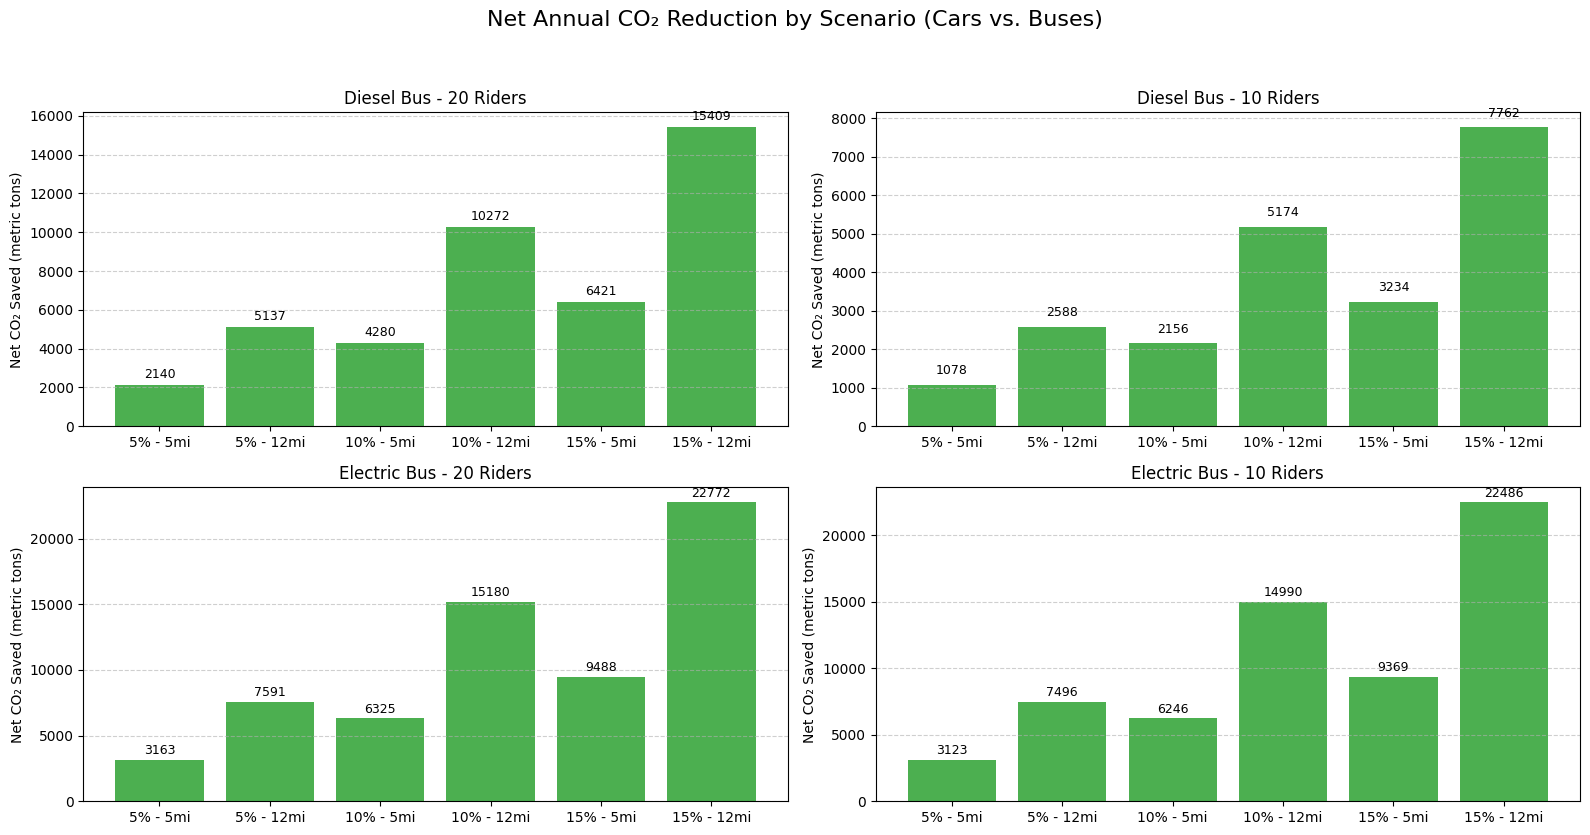

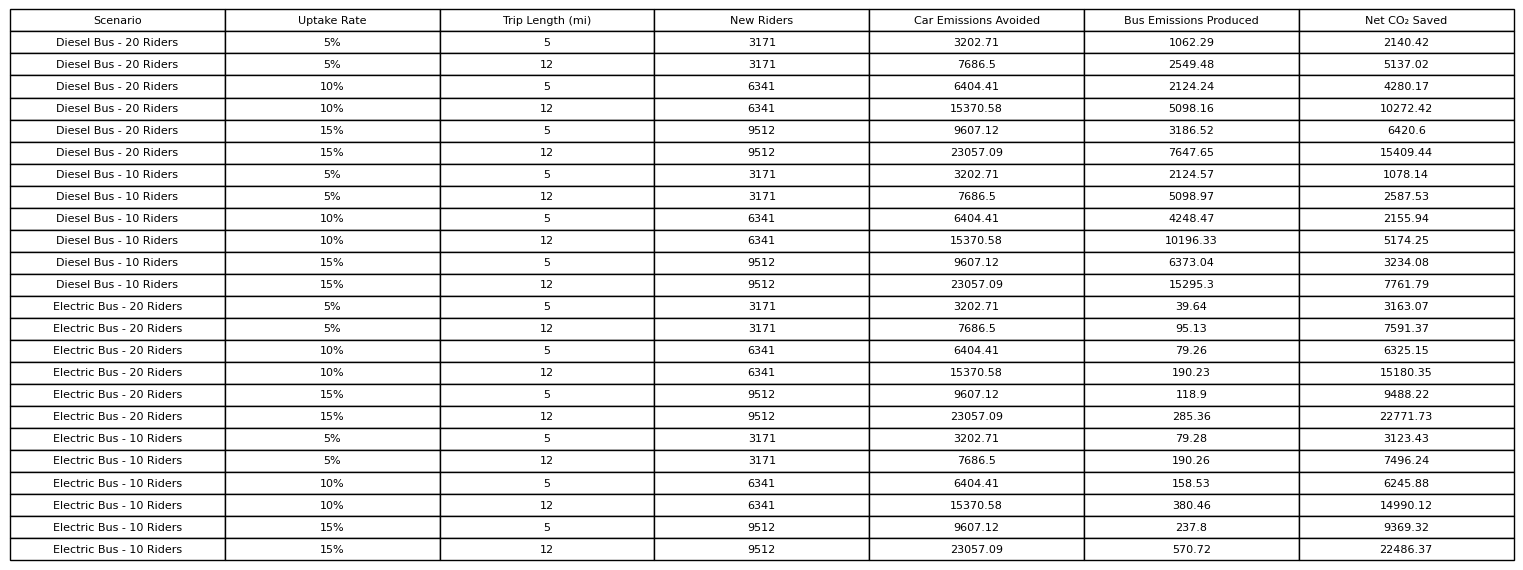

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Constants
population_served = 63413 #Affected number of people From GIS Analysis
uptake_rates = [0.05, 0.10, 0.15] #Probable uptake values
trip_lengths = [5, 12] #Avg trip length in america is 12 miles
emissions_per_mile_car = 404 #National Average
emissions_per_mile_bus_diesel = 2680 #National Average
emissions_per_mile_bus_electric = 100  # approximate grid-based indirect emissions
commuting_days = 250

# Function to calculate emissions
def annual_emissions(trip_miles, emission_per_mile, occupancy):
    per_person_per_mile = emission_per_mile / occupancy
    return (trip_miles * 2 * per_person_per_mile * commuting_days) / 1e6  # to tons

def annual_car_emissions(trip_miles):
    return (trip_miles * 2 * emissions_per_mile_car * commuting_days) / 1e6

# Scenario configs
scenarios = [
    ("Diesel Bus - 20 Riders", emissions_per_mile_bus_diesel, 20),
    ("Diesel Bus - 10 Riders", emissions_per_mile_bus_diesel, 10),
    ("Electric Bus - 20 Riders", emissions_per_mile_bus_electric, 20),
    ("Electric Bus - 10 Riders", emissions_per_mile_bus_electric, 10)
]

# Data containers
master_table = []

# Visualization layout
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Net Annual CO₂ Reduction by Scenario (Cars vs. Buses)", fontsize=16)

# Loop through scenarios
for idx, (scenario_label, bus_emission_rate, occupancy) in enumerate(scenarios):
    scenario_data = []
    net_savings = []
    labels = []

    for uptake in uptake_rates:
        new_riders = round(population_served * uptake)
        for trip in trip_lengths:
            car_emission = annual_car_emissions(trip)
            bus_emission = annual_emissions(trip, bus_emission_rate, occupancy)

            total_car_savings = round(car_emission * new_riders, 2)
            total_bus_emission = round(bus_emission * new_riders, 2)
            net = round(total_car_savings - total_bus_emission, 2)

            label = f"{int(uptake*100)}% - {trip}mi"
            net_savings.append(net)
            labels.append(label)

            # Add to master table
            master_table.append({
                "Scenario": scenario_label,
                "Uptake Rate": f"{int(uptake*100)}%",
                "Trip Length (mi)": trip,
                "New Riders": new_riders,
                "Car Emissions Avoided": total_car_savings,
                "Bus Emissions Produced": total_bus_emission,
                "Net CO₂ Saved": net
            })

    # Plot
    ax = axs[idx // 2][idx % 2]
    bars = ax.bar(labels, net_savings, color="#4caf50")
    ax.set_title(scenario_label, fontsize=12)
    ax.set_ylabel("Net CO₂ Saved (metric tons)")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 200, f'{yval:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0.15, 1, 0.95])
plt.savefig("net_emissions_comparison_charts.png", dpi=300)
plt.show()

# Master table output
df = pd.DataFrame(master_table)

# Table-only plot
fig2, ax2 = plt.subplots(figsize=(16, 6))
ax2.axis('off')
table = ax2.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.4, 1.5)

plt.tight_layout()
plt.savefig("net_emissions_comparison_table.png", dpi=300)
plt.show()


In [2]:
average_saved = round(df["Net CO₂ Saved"].mean(), 2)
print(f"Average net CO₂ saved: {average_saved} metric tons/year")

Average net CO₂ saved: 8078.46 metric tons/year
